## Solve a simple differential equation
$
\frac{d^2 u}{dx^2} - (x^6 - 3x^2) u = 0
$


--------

In [ ]:
import sys
import os
import math
import numpy as np
import scipy

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
%config InlineBackend.figure_format = 'retina'

import seaborn as sns

context=['paper', 'notebook', 'talk', 'poster'] [1]
palette=['deep', 'muted', 'bright', 'pastel', 'dark', 'colorblind', 'hls', 'tab10'] [2]
style=['darkgrid', 'whitegrid', 'dark', 'white', 'ticks'] [4]


rc={"axes.grid":"false", #"true",
    "axes.grid.which": "major",
    "grid.color":'lightgrey',
    "grid.linewidth":0.6,
    'xtick.direction':'in',
    'xtick.top':True,
    'ytick.direction':'in',
    'ytick.right':True
    }

sns.set_theme(style=style,context=context, palette=palette,
              font_scale=1, rc=rc)
print(sys.version)
print("Seaborn version {}".format(sns.__version__))

3.11.0 | packaged by conda-forge | (main, Jan 14 2023, 12:27:40) [GCC 11.3.0]
Seaborn version 0.12.2


In [1]:
# help for calculus and algebra
import sympy

In [2]:
x, a0, a1, a2 = sympy.symbols("x a0 a1 a2")

uN = 1 + (1 - x**2) * (a0 + a1 * x + a2 * x**2)
ddu_dxdx = sympy.simplify(sympy.diff(uN, x, x))

print(f"u''={ddu_dxdx}")

u''=-2*a0 - 6*a1*x - 12*a2*x**2 + 2*a2


In [10]:
Residual = sympy.simplify(ddu_dxdx - (x**6 + 3 * x**2) * uN)

print(f"Residual={Residual}")

Residual=-2*a0 - 6*a1*x - 12*a2*x**2 + 2*a2 + x**2*(x**4 + 3)*((x**2 - 1)*(a0 + a1*x + a2*x**2) - 1)


In [11]:
r0 = Residual.subs(x, 0.5)
r1 = Residual.subs(x, 0.0)
r2 = Residual.subs(x, -0.5)

print(f"R(0.5) = {r0}\nR(0) = {r1}\nR(-0.5) = {r2}")

R(0.5) = -2.57421875*a0 - 3.287109375*a1 - 1.1435546875*a2 - 0.765625
R(0) = -2*a0 + 2*a2
R(-0.5) = -2.57421875*a0 + 3.287109375*a1 - 1.1435546875*a2 - 0.765625


In [5]:
sympy.linsolve?

Signature: sympy.linsolve(system, *symbols)
Docstring:
Solve system of $N$ linear equations with $M$ variables; both
underdetermined and overdetermined systems are supported.
The possible number of solutions is zero, one or infinite.
Zero solutions throws a ValueError, whereas infinite
solutions are represented parametrically in terms of the given
symbols. For unique solution a :class:`~.FiniteSet` of ordered tuples
is returned.

All standard input formats are supported:
For the given set of equations, the respective input types
are given below:

.. math:: 3x + 2y -   z = 1
.. math:: 2x - 2y + 4z = -2
.. math:: 2x -   y + 2z = 0

* Augmented matrix form, ``system`` given below:

$$ \text{system} = \left[{array}{cccc}
    3 &  2 & -1 &  1\\
    2 & -2 &  4 & -2\\
    2 & -1 &  2 &  0
    \end{array}\right] $$

::

    system = Matrix([[3, 2, -1, 1], [2, -2, 4, -2], [2, -1, 2, 0]])

* List of equations form

::

    system  =  [3x + 2y - z - 1, 2x - 2y + 4z + 2, 2x - y + 2z]

* Input $A$

In [12]:
# print(f"previous solution (+-0.5)={soln}")
soln = sympy.linsolve([r0, r1, r2], (a0, a1, a2))
print(f"solution={soln}")

solution={(-0.205936432886787, 0, -0.205936432886788)}


In [13]:
# back to standard Python + numpy
a0_, a1_, a2_ = list(soln)[0]  # get rid of Sympy's FiniteSet
print(f"a0 = {a0_}, a1 = {a1_}, a2 = {a2_}")

a0 = -0.205936432886787, a1 = 0, a2 = -0.205936432886788


In [8]:
# Define exact solution
uf = sympy.exp((x**4 - 1) / 4)

# Show that its really the solution
ddudx2 = sympy.diff(uf, x, x)
for val in np.arange(-1, 1, 0.2):
    print(f"Residual at x = {val}:\t {(ddudx2 - (x**6 + 3 * x**2) * uf).subs(x, 0.3)}")

Residual at x = -1.0:	 0
Residual at x = -0.8:	 0
Residual at x = -0.6000000000000001:	 0
Residual at x = -0.40000000000000013:	 0
Residual at x = -0.20000000000000018:	 0
Residual at x = -2.220446049250313e-16:	 0
Residual at x = 0.19999999999999973:	 0
Residual at x = 0.3999999999999997:	 0
Residual at x = 0.5999999999999996:	 0
Residual at x = 0.7999999999999996:	 0


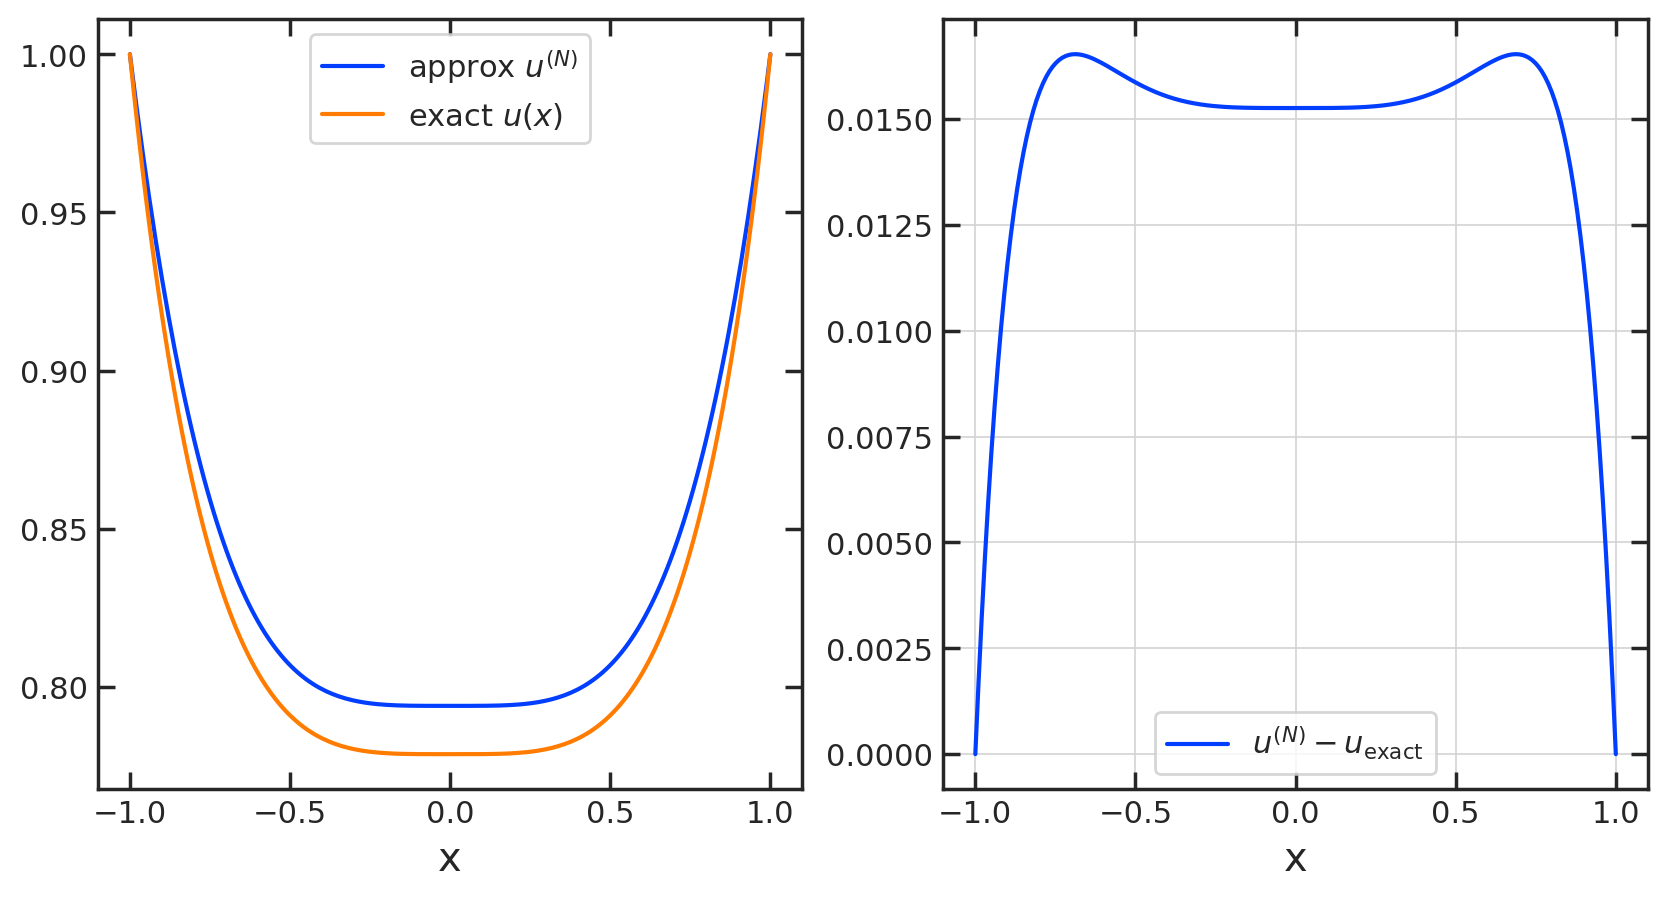

In [9]:
# evaluate our approximate solution and the exact solution
x_ = np.linspace(-1, 1, num=200)
u_approx = 1 + (1 - x_**2) * (a0_ + a1_ * x_ + a2_ * x_**2)
u_exact = np.exp((x_**4 - 1) / 4)


# PLOT
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(x_, u_approx, label=r"approx $u^{(N)}$")
axs[0].plot(x_, u_exact, label="exact $u(x)$")
axs[1].plot(x_, u_approx - u_exact, label=r"$u^{(N)}-u_{\rm exact}$")
axs[0].set_xlabel("x", fontsize="larger")
axs[1].set_xlabel("x", fontsize="larger")
axs[0].legend()
axs[1].legend()
axs[1].grid()